<a href="https://colab.research.google.com/github/nmreimer/461GraphMLProject/blob/main/GNN_LLM_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install & Import Packages

In [1]:
import sys, torch, subprocess

print("Kernel Python:", sys.version)
print("Torch:", torch.__version__, "| CUDA:", torch.version.cuda or "cpu")

# Build the correct PyG index URL for your Torch/CUDA
torch_ver = torch.__version__.split('+')[0]
cuda = torch.version.cuda
suffix = f"cu{cuda.replace('.','')}" if cuda else "cpu"
index_url = f"https://data.pyg.org/whl/torch-{torch_ver}+{suffix}.html"
print("Using PyG index:", index_url)

# Ensure pip targets THIS interpreter
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "pip<25"])

# Install all required PyG wheels into THIS Python
subprocess.check_call([sys.executable, "-m", "pip", "install", "-f", index_url,
                       "pyg-lib", "torch-scatter", "torch-sparse",
                       "torch-cluster", "torch-spline-conv", "torch-geometric",
                       "--no-cache-dir"])

# Chemistry deps into THIS Python
subprocess.check_call([sys.executable, "-m", "pip", "install", "rdkit", "deepchem"])


Kernel Python: 3.11.8 (main, Feb 26 2024, 15:36:12) [Clang 14.0.6 ]
Torch: 2.8.0 | CUDA: cpu
Using PyG index: https://data.pyg.org/whl/torch-2.8.0+cpu.html
  Obtaining dependency information for pip<25 from https://files.pythonhosted.org/packages/ef/7d/500c9ad20238fcfcb4cb9243eede163594d7020ce87bd9610c9e02771876/pip-24.3.1-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 9.2 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 23.2.1
    Uninstalling pip-23.2.1:
      Successfully uninstalled pip-23.2.1



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


Looking in links: https://data.pyg.org/whl/torch-2.8.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 12.1 MB/s eta 0:00:00:--:--



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


0

In [2]:
from re import I
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import random
import numpy as np

import torch
from torch.utils.data import Subset
from torch_geometric.datasets import MoleculeNet

from deepchem.splits import ScaffoldSplitter
from deepchem.data import NumpyDataset

/Users/yvonney/anaconda3/lib/python3.11/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: dlopen(/Users/yvonney/anaconda3/lib/python3.11/site-packages/torch_scatter/_version_cpu.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <91D0B366-1320-3144-82EB-9F1EAE9C725D> /Users/yvonney/anaconda3/lib/python3.11/site-packages/torch_scatter/_version_cpu.so
  Expected in:     <B6BD92AE-4D03-3F92-9E03-2E2594A12866> /Users/yvonney/anaconda3/lib/python3.11/site-packages/torch/lib/libtorch_cpu.dylib
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/Users/yvonney/anaconda3/lib/python3.11/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: dlopen(/Users/yvonney/anaconda3/lib/python3.11/site-packages/torch_cluster/_version_cpu.so, 0x0006): Symbol not found: __ZN3c1017Regi

Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
/Users/yvonney/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/Users/yvonney/anaconda3/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <2BD1B165-EC09-3F68-BCE4-8FE4E70CA7E2> /Users/yvonney/anaconda3/lib/python3.11/site-packages/torchvision/image.so
  Expected in:     <B6BD92AE-4D03-3F92-9E03-2E2594A12866> /Users/yvonney/anaconda3/lib/python3.11/site-packages/torch/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No mo

## Load BBBP dataset

In [4]:
from loadMoleculeData import load_datasets

# Load only BBBP using the shared loader (scaffold split inside)
datasets = load_datasets(names=["BBBP"], root="data/moleculenet", scaffold="standard")
bbbp = datasets[0]
train_set = bbbp['train_set']
val_set   = bbbp['val_set']
test_set  = bbbp['test_set']

Processing...
/Users/yvonney/anaconda3/lib/python3.11/site-packages/torch_geometric/datasets/molecule_net.py:213: UserWarning: Skipping molecule 'O=N([O-])C1=C(CN=C1NCCSCc2ncccc2)Cc3ccccc3' since it resulted in zero atoms
  warnings.warn(f"Skipping molecule '{smiles}' since it "
/Users/yvonney/anaconda3/lib/python3.11/site-packages/torch_geometric/datasets/molecule_net.py:213: UserWarning: Skipping molecule 'c1(nc(NC(N)=[NH2])sc1)CSCCNC(=[NH]C#N)NC' since it resulted in zero atoms
  warnings.warn(f"Skipping molecule '{smiles}' since it "
/Users/yvonney/anaconda3/lib/python3.11/site-packages/torch_geometric/datasets/molecule_net.py:213: UserWarning: Skipping molecule 'Cc1nc(sc1)\[NH]=C(\N)N' since it resulted in zero atoms
  warnings.warn(f"Skipping molecule '{smiles}' since it "
/Users/yvonney/anaconda3/lib/python3.11/site-packages/torch_geometric/datasets/molecule_net.py:213: UserWarning: Skipping molecule 's1cc(CSCCN\C(NC)=[NH]\C#N)nc1\[NH]=C(\N)N' since it resulted in zero atoms
  w

### EDA

Train set size: 1631
Validation set size: 204
Test set size: 204
Number of features: 9
Class balance: [ 479 1560]


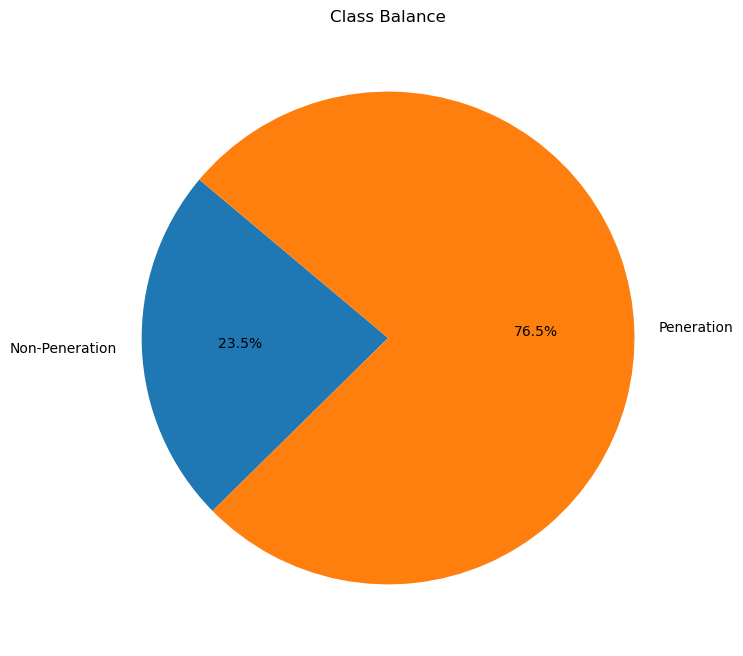

In [5]:
print(f"Train set size: {len(train_set)}")
print(f"Validation set size: {len(val_set)}")
print(f"Test set size: {len(test_set)}")

print(f"Number of features: {train_set.dataset.num_features}")

#check balance of classes
labels = []
labels.extend([float(d.y.item()) for d in train_set])
labels.extend([float(d.y.item()) for d in val_set])
labels.extend([float(d.y.item()) for d in test_set])
print(f"Class balance: {np.bincount(labels)}")
# pie chart of class balance
plt.figure(figsize=(8, 8))
plt.pie(np.bincount(labels), labels=["Non-Peneration", "Peneration"], autopct='%1.1f%%', startangle=140)
plt.title("Class Balance")
plt.show()

## GNN (baselinemodeling.ipynb)

In [48]:
from torch_geometric.loader import DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
import numpy as np

# Use the shared baseline model utilities
from baselineGCN import GCN, do_epoch, device

In [49]:
batch_size = 256
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False)

# Initialize model to match dataset's feature dimensionality
in_channels = train_set.dataset.num_features
model = GCN(in_channels=in_channels, hidden_channels=128, num_layers=3)
model = model.to(device)

# Load pretrained checkpoint for BBBP
ckpt_path = "models/baselineGCN_BBBP.pt"
state = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state)
model.eval()

GCN(
  (convs): ModuleList(
    (0): GCNConv(9, 128)
    (1-2): 2 x GCNConv(128, 128)
  )
  (lin): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [50]:
# Evaluate pretrained model on validation and test (no retraining)
criterion = nn.BCEWithLogitsLoss()
val_loss, val_auc = do_epoch(val_loader, training=False, model=model, criterion=criterion)
test_loss, test_auc = do_epoch(test_loader, training=False, model=model, criterion=criterion)
print(f"Validation: loss {val_loss:.4f} AUC {val_auc:.3f}")
print(f"Test:       loss {test_loss:.4f} AUC {test_auc:.3f}")

Validation: loss 0.4000 AUC 0.908
Test:       loss 0.7914 AUC 0.678


## LLM-Boosted Prediction Correction



### K-Most Similar using Tanimoto

In [51]:
# Get SMILES and labels from current splits (no direct dataset/train_idx references)
base_ds = train_set.dataset  # original MoleculeNet dataset

# Subset stores original indices in .indices; fall back to 0..len-1 if absent
train_indices = getattr(train_set, 'indices', list(range(len(train_set))))
test_indices  = getattr(test_set,  'indices',  list(range(len(test_set))))

train_smiles = [base_ds[i].smiles for i in train_indices]
test_smiles  = [base_ds[i].smiles for i in test_indices]
train_labels = [float(base_ds[i].y.item()) for i in train_indices]
test_labels  = [float(base_ds[i].y.item()) for i in test_indices]


In [52]:
from typing import List, Literal, Optional, Iterable, Dict, Any
import numpy as np
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, RDKFingerprint

# SMILES to molecule fingerprint
def smiles_to_fingerprint(
    smiles: str,
    kind: Literal["morgan", "rdk"] = "morgan",
    radius: int = 2,
    nBits: int = 2048
):
    """Covert each SMILES to RDkit fingerprint, return None if fails"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    if kind == "morgan":
        return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
    elif kind == "rdk":
        return RDKFingerprint(mol, fpSize=nBits)
    else:
        raise ValueError("Unknown fingerprint kind")

def batch_smiles_to_fps(
    smiles_list: Iterable[str],
    kind: Literal["morgan", "rdk"] = "morgan",
    radius: int = 2,
    nBits: int = 2048
):
    return [smiles_to_fingerprint(s, kind=kind, radius=radius, nBits=nBits) for s in smiles_list]

# K-most similar
def find_k_most_similar_molecules(
    test_smiles: Iterable[str],
    train_smiles: Iterable[str],
    y_train: Iterable[Any],
    k_neighbors: int = 5,
    fp_kind: Literal["morgan", "rdk"] = "morgan",
    fp_radius: int = 2,
    fp_nBits: int = 2048,
    return_indices: bool = True
) -> List[Dict[str, Any]]:
    """
    For each test molecule, find the K most similar molecules in the training set based on Tanimoto similarity.
    Return a list, where each element is a dictionary containing the information of the K nearest neighbors for that test sample.
    """
    # 1) Precompute fingerprints of the training set (done once, reused for all test samples)
    train_smiles = list(train_smiles)
    y_train = np.asarray(list(y_train))
    train_fps = batch_smiles_to_fps(train_smiles, kind=fp_kind, radius=fp_radius, nBits=fp_nBits)

    # Record which training samples are invalid (SMILES parsing failed)
    valid_train = np.array([fp is not None for fp in train_fps])
    if not valid_train.any():
        raise ValueError("No valid fingerprints in training set.")
    valid_train_fps = [fp for fp in train_fps if fp is not None]
    valid_train_smiles = [s for s, v in zip(train_smiles, valid_train) if v]
    valid_y_train = y_train[valid_train]

    results = []

    # 2) Iterate through the test set, compute BulkTanimoto similarity with all training samples, then take Top-K
    for q_idx, q_smiles in enumerate(test_smiles):
        q_fp = smiles_to_fingerprint(q_smiles, kind=fp_kind, radius=fp_radius, nBits=fp_nBits)
        if q_fp is None:
            results.append({
                "test_index": q_idx,
                "test_smiles": q_smiles,
                "neighbors_smiles": [],
                "neighbors_labels": [],
                "neighbors_similarity": [],
                "neighbors_indices_in_train": [] if return_indices else None,
                "note": "invalid test SMILES"
            })
            continue

        # The larger the value, the more similar
        sims = np.array(DataStructs.BulkTanimotoSimilarity(q_fp, valid_train_fps), dtype=float)

        # Select the top K indices (Argpartition first, then sort by similarity in descending order)
        k = min(k_neighbors, sims.size)
        topk_idx = np.argpartition(sims, -k)[-k:]
        topk_idx = topk_idx[np.argsort(sims[topk_idx])[::-1]]

        results.append({
            "test_index": q_idx,
            "test_smiles": q_smiles,
            "neighbors_smiles": [valid_train_smiles[i] for i in topk_idx],
            "neighbors_labels":  [valid_y_train[i]    for i in topk_idx],
            "neighbors_similarity": sims[topk_idx].tolist(),
            "neighbors_indices_in_train": (
                np.nonzero(valid_train)[0][topk_idx].tolist() if return_indices else None
            )
        })

    return results

In [10]:
import pandas as pd
from tabulate import tabulate

# Example data (fake data)
data = [
    ["CC1=CC=CC=C1C(=O)NCCO", 1, 1.00],   # Query molecule
    ["CC1=CC=CC=C1C(=O)O", 0, 0.89],
    ["CCOC(=O)C1=CC=CC=C1", 1, 0.83],
    ["CC1=CC=C(C=C1)OCCO", 1, 0.81],
    ["CC(=O)NC1=CC=CC=C1", 1, 0.78],
    ["COC1=CC=CC=C1C(=O)O", 0, 0.76],
]

# Create DataFrame
df = pd.DataFrame(data, columns=["SMILES", "True Label (y)", "Similarity"])

# Display table with grid lines
print(tabulate(df, headers='keys', tablefmt='grid', showindex=False))


+-----------------------+------------------+--------------+
| SMILES                |   True Label (y) |   Similarity |
+=======================+==================+==============+
| CC1=CC=CC=C1C(=O)NCCO |                1 |         1    |
+-----------------------+------------------+--------------+
| CC1=CC=CC=C1C(=O)O    |                0 |         0.89 |
+-----------------------+------------------+--------------+
| CCOC(=O)C1=CC=CC=C1   |                1 |         0.83 |
+-----------------------+------------------+--------------+
| CC1=CC=C(C=C1)OCCO    |                1 |         0.81 |
+-----------------------+------------------+--------------+
| CC(=O)NC1=CC=CC=C1    |                1 |         0.78 |
+-----------------------+------------------+--------------+
| COC1=CC=CC=C1C(=O)O   |                0 |         0.76 |
+-----------------------+------------------+--------------+


### LLM Preparation

In [53]:
import time, random, re, os
import google.generativeai as genai
from typing import Optional


GEMINI_MODEL = "gemini-2.5-flash"

# 1) Prompt builder (molecule version, same signature style you used before)
def prompt_for_llm(current_molecule_smiles, initial_pred_gnn, similar_historical_molecules):
    return f"""
You are assisting with molecular property prediction. Improve a baseline GNN prediction using K similar labeled molecules.

Tasks:
1) Using the current molecule's SMILES + K most similar training molecules (with ground-truth labels),
   adjust the initial prediction from a GNN.
2) Return ONLY a single number (float). No text, no units.

Current molecule (SMILES): {current_molecule_smiles}
GNN initial (ŷ): {initial_pred_gnn}

K similar molecules (each line: SMILES | label y | similarity):
{similar_historical_molecules}

Answer with just the number.
""".strip()

# 2) Numeric parser (kept same behavior)
_number_re = re.compile(r"[-+]?(?:\d+\.\d+|\d+)(?:[eE][-+]?\d+)?")
def parse_float(s: str) -> float:
    m = _number_re.search(s)
    if not m:
        raise ValueError(f"Could not find a numeric answer in: {s!r}")
    return float(m.group(0))

# Helper to read Gemini API key from file or env
_DEF_SECRET_PATH = os.path.join(".secrets", "gemini_api_key.txt")

def load_gemini_api_key(explicit_key: Optional[str] = None) -> Optional[str]:
    if explicit_key and explicit_key.strip():
        return explicit_key.strip()
    env_key = os.getenv("GOOGLE_API_KEY")
    if env_key and env_key.strip():
        return env_key.strip()
    try:
        with open(_DEF_SECRET_PATH, "r", encoding="utf-8") as f:
            key = f.read().strip()
            if key:
                return key
    except FileNotFoundError:
        pass
    return None

# 3) Minimal Gemini client with a .generate(prompt) method ---------------------
class _GeminiClient:
    """
    Tiny wrapper so we can call client.generate(prompt) just like before.
    """

    def __init__(self, api_key: Optional[str] = None, model: str = GEMINI_MODEL):
        key = load_gemini_api_key(api_key)
        if not key:
            raise ValueError(
                "Provide gemini_api_key, set GOOGLE_API_KEY, or create .secrets/gemini_api_key.txt"
            )
        genai.configure(api_key=key)

        # System-style instruction to force numeric-only replies
        self.model = genai.GenerativeModel(
            model,
            system_instruction="Return only a single number (float). No text, no units."
        )

        # Optional: tune generation config for determinism
        self.generation_config = {
            "temperature": 0.0,
            "top_p": 0.0,
            "top_k": 1,
        }

        # Optional safety settings (relaxed but safe defaults)
        self.safety_settings = {
            # keep defaults or customize if your org requires
        }

    def generate(self, prompt: str) -> str:
        resp = self.model.generate_content(
            prompt,
            generation_config=self.generation_config,
            safety_settings=self.safety_settings
        )
        # Handle blocked or empty responses
        if not hasattr(resp, "text") or resp.text is None:
            # Sometimes the SDK returns candidates; fall back to first candidate text if present
            try:
                cand = resp.candidates[0]
                parts = getattr(cand.content, "parts", None)
                if parts:
                    text = "".join(getattr(p, "text", "") for p in parts if getattr(p, "text", None))
                    if text.strip():
                        return text.strip()
            except Exception:
                pass
            raise RuntimeError(f"Empty/blocked Gemini response: {resp}")
        return resp.text.strip()


def build_gemini_client(gemini_api_key: Optional[str] = None, model: str = GEMINI_MODEL):
    return _GeminiClient(api_key=gemini_api_key, model=model)

# 4) Retry/backoff wrapper
def call_llm_with_retry(client, prompt, max_attempts=8, base_sleep=0.8, max_sleep=20.0, **_):
    """
    Returns raw text from Gemini. Your downstream code still calls parse_float(text).
    """
    attempt = 0
    while True:
        attempt += 1
        try:
            text = client.generate(prompt)
            if not text.strip():
                raise RuntimeError("Empty response from model")
            return text.strip()
        except Exception as e:
            msg = str(e).lower()
            retriable = any(x in msg for x in [
                "timeout", "temporarily", "unavailable", "connection reset",
                "read timed out", "overloaded", "quota", "rate limit", "429", "503"
            ])
            if not retriable or attempt >= max_attempts:
                raise
            sleep_s = min(max_sleep, base_sleep * (2 ** (attempt - 1)))
            sleep_s *= random.uniform(0.7, 1.3)
            time.sleep(sleep_s)


# 5) Initialize client
try:
    del client  # remove old OpenAI client binding if it exists
except NameError:
    pass

# Allow override via a global `gemini_api_key` if user set it; else env/file
client = build_gemini_client(gemini_api_key=globals().get("gemini_api_key", None), model=GEMINI_MODEL)


In [54]:
import time, random, re, os
import google.generativeai as genai
from typing import Optional

# Configure from env or .secrets (handled in previous cell via _GeminiClient)
# Remove any hardcoded key usage.
for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(m.name)

E0000 00:00:1760886927.711482 67043442 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


models/gemini-2.5-pro-preview-03-25
models/gemini-2.5-flash-preview-05-20
models/gemini-2.5-flash
models/gemini-2.5-flash-lite-preview-06-17
models/gemini-2.5-pro-preview-05-06
models/gemini-2.5-pro-preview-06-05
models/gemini-2.5-pro
models/gemini-2.0-flash-exp
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-exp-image-generation
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.0-flash-preview-image-generation
models/gemini-2.0-flash-lite-preview-02-05
models/gemini-2.0-flash-lite-preview
models/gemini-2.0-pro-exp
models/gemini-2.0-pro-exp-02-05
models/gemini-exp-1206
models/gemini-2.0-flash-thinking-exp-01-21
models/gemini-2.0-flash-thinking-exp
models/gemini-2.0-flash-thinking-exp-1219
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/learnlm-2.0-flash-experimental
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models

### Main loop

In [55]:
# TODO: Investigate Deprecation warning relating to MorganGenerator

k = 5

# find k-most similar using tanimoto
results = find_k_most_similar_molecules(
    test_smiles=test_smiles,
    train_smiles=train_smiles,
    y_train=train_labels,
    k_neighbors=k,
    fp_kind="morgan",
    fp_radius=2,
    fp_nBits=2048,
)

# convert structure
def to_neighbor_list(res_i):
    return [
        {
            "smiles": s,
            "y_true": float(y) if str(y).replace('.','',1).isdigit() else y,
            "tanimoto": float(sim)
        }
        for s, y, sim in zip(
            res_i["neighbors_smiles"],
            res_i["neighbors_labels"],
            res_i["neighbors_similarity"]
        )
    ]

similar_mols = [to_neighbor_list(r) for r in results]

[10:15:27] DEPRECATION WARNING: please use MorganGenerator
[10:15:27] DEPRECATION WARNING: please use MorganGenerator
[10:15:27] DEPRECATION WARNING: please use MorganGenerator
[10:15:27] DEPRECATION WARNING: please use MorganGenerator
[10:15:27] DEPRECATION WARNING: please use MorganGenerator
[10:15:27] DEPRECATION WARNING: please use MorganGenerator
[10:15:27] DEPRECATION WARNING: please use MorganGenerator
[10:15:27] DEPRECATION WARNING: please use MorganGenerator
[10:15:27] DEPRECATION WARNING: please use MorganGenerator
[10:15:27] DEPRECATION WARNING: please use MorganGenerator
[10:15:27] DEPRECATION WARNING: please use MorganGenerator
[10:15:27] DEPRECATION WARNING: please use MorganGenerator
[10:15:27] DEPRECATION WARNING: please use MorganGenerator
[10:15:27] DEPRECATION WARNING: please use MorganGenerator
[10:15:27] DEPRECATION WARNING: please use MorganGenerator
[10:15:27] DEPRECATION WARNING: please use MorganGenerator
[10:15:27] DEPRECATION WARNING: please use MorganGenerat

In [56]:
import torch
import numpy as np

# Get initial prediction results from GNN and true labels
@torch.no_grad()
def predict_proba_from_loader(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    all_smiles, all_indices = [], []

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)
        probs  = torch.sigmoid(logits)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(batch.y.view(-1).cpu().numpy())

        # If the Data object contains smiles / idx, collect them here to align with upstream data
        if hasattr(batch, "smiles"):
            # torch_geometric’s Data/Batch won’t automatically merge strings; need to include list[str] when constructing the dataset
            all_smiles += list(batch.smiles)
        if hasattr(batch, "idx"):
            all_indices += batch.idx.cpu().tolist()

    return (np.concatenate(all_probs),
            np.concatenate(all_labels),
            all_smiles if len(all_smiles) > 0 else None,
            all_indices if len(all_indices) > 0 else None)

y_pred_gnn_initial, y_test, test_smiles_from_batch, test_indices = predict_proba_from_loader(model, test_loader, device)
# y_pred_gnn_initial: np.ndarray, len(test_set)，value 0~1
# y_test: np.ndarray, true label 0~1, same length

In [57]:
# Main loop for LLM-Boosted Prediction Correction

import numpy as np
import pandas as pd

def format_neighbors(neighbor_list):
    """
    neighbor_list: [{"smiles": str, "y_true": float, "tanimoto": float}, ...]
    Returns a multi-line string for the prompt.
    """
    if not neighbor_list:
        return "None"
    lines = []
    for i, nb in enumerate(neighbor_list, 1):
        lines.append(f"{i}. SMILES: {nb['smiles']} | y: {float(nb['y_true']):.6g} | Tanimoto: {float(nb['tanimoto']):.3f}")
    return "\n".join(lines)

# Collect results: [llm_pred, gnn_initial, y_true]
results_list = []

# --- main loop ---
for i in range(len(test_smiles)):
    print(f"\n=== Start sample {i}/{len(test_smiles)} ===")
    current_smiles = test_smiles[i]
    initial_pred_gnn = float(y_pred_gnn_initial[i])
    k_neighbors_block = format_neighbors(similar_mols[i])

    prompt = prompt_for_llm(current_smiles, initial_pred_gnn, k_neighbors_block)
    print("Prompt built, length:", len(prompt))

    try:
        raw = call_llm_with_retry(client, prompt, model="gemini-2.5-flash")
        print("Received raw response.")
    except Exception as e:
        print(f" LLM call failed at index {i}:", e)
        continue

    y_llm = parse_float(raw)
    print("Parsed y_llm:", y_llm)

    results_list.append([y_llm, initial_pred_gnn, float(y_test.iloc[i] if hasattr(y_test, "iloc") else y_test[i])])

# Turn into DataFrame (same shape/labels as your flight project)
dt_final = pd.DataFrame(results_list, columns=["LLM_Prediction", "GNN_Initial", "Actual_Label"])

# Metrics
y_true = dt_final["Actual_Label"].to_numpy()
y_llm  = dt_final["LLM_Prediction"].to_numpy()
y_gnn  = dt_final["GNN_Initial"].to_numpy()

mse_corrected = np.mean((y_llm - y_true) ** 2)
mse_gnn       = np.mean((y_gnn - y_true) ** 2)

print(f"MSE of LLM-Boosted Prediction Correction: {mse_corrected:.4f}")
print(f"MSE of GNN baseline: {mse_gnn:.4f}")

# (Optional) inspect worst LLM error index like you did before
dt_final["error_llm"] = dt_final["LLM_Prediction"] - dt_final["Actual_Label"]
worst_idx = int(dt_final["error_llm"].idxmax())
print("Index with largest positive LLM error:", worst_idx)



=== Start sample 0/204 ===
Prompt built, length: 947


E0000 00:00:1760886929.949275 67043442 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


Received raw response.
Parsed y_llm: 0.8082830309867859

=== Start sample 1/204 ===
Prompt built, length: 948
Received raw response.
Parsed y_llm: 0.885095404139903

=== Start sample 2/204 ===
Prompt built, length: 1098
Received raw response.
Parsed y_llm: 0.8426595330238342

=== Start sample 3/204 ===
Prompt built, length: 859
Received raw response.
Parsed y_llm: 0.8829983761785142

=== Start sample 4/204 ===
Prompt built, length: 923
Received raw response.
Parsed y_llm: 0.9923440159524305

=== Start sample 5/204 ===
Prompt built, length: 907
Received raw response.
Parsed y_llm: 0.6685999999999999

=== Start sample 6/204 ===
Prompt built, length: 818
Received raw response.
Parsed y_llm: 0.41595253348350525

=== Start sample 7/204 ===
Prompt built, length: 838
Received raw response.
Parsed y_llm: 0.9592058956623077

=== Start sample 8/204 ===
Prompt built, length: 914
Received raw response.
Parsed y_llm: 0.8933062553405762

=== Start sample 9/204 ===
Prompt built, length: 879
Received 

In [58]:
# Run stopped at sample 200/204 due to exceeding the API request quota; now continuing with the remaining samples.

# Results of the remaining
results_list = []

# Remaining samples
for i in [200, 201, 202, 203]:
    print(f"\n=== Start sample {i} ===")
    current_smiles = test_smiles[i]
    initial_pred_gnn = float(y_pred_gnn_initial[i])
    k_neighbors_block = format_neighbors(similar_mols[i])

    prompt = prompt_for_llm(current_smiles, initial_pred_gnn, k_neighbors_block)
    print("Prompt built, length:", len(prompt))

    try:
        raw = call_llm_with_retry(client, prompt, model="gemini-2.5-flash")
        print("Received raw response.")
    except Exception as e:
        print(f" LLM call failed at index {i}:", e)
        continue

    y_llm = parse_float(raw)
    print("Parsed y_llm:", y_llm)

    results_list.append([y_llm, initial_pred_gnn, float(y_test.iloc[i] if hasattr(y_test, "iloc") else y_test[i])])

dt_rest = pd.DataFrame(results_list, columns=["LLM_Prediction", "GNN_Initial", "Actual_Label"])

# Concat two dataframes
dt_final = pd.concat([dt_final.iloc[:-4], dt_rest], ignore_index=True)

# Final Metrics
y_true = dt_final["Actual_Label"].to_numpy()
y_llm  = dt_final["LLM_Prediction"].to_numpy()
y_gnn  = dt_final["GNN_Initial"].to_numpy()

mse_corrected = np.mean((y_llm - y_true) ** 2)
mse_gnn = np.mean((y_gnn - y_true) ** 2)

print(f"MSE of LLM-Boosted Prediction Correction: {mse_corrected:.4f}")
print(f"MSE of GNN baseline: {mse_gnn:.4f}")

# (Optional) inspect worst LLM error index like you did before
dt_final["error_llm"] = dt_final["LLM_Prediction"] - dt_final["Actual_Label"]
worst_idx = int(dt_final["error_llm"].idxmax())
print("Index with largest positive LLM error:", worst_idx)

# Consider splitting the loop into smaller batches (e.g., 50–100 samples per run) or adding short delays between requests，
# to avoid hitting the API rate or quota limits in future runs.


=== Start sample 200 ===
Prompt built, length: 971
Received raw response.
Parsed y_llm: 0.7896341242136004

=== Start sample 201 ===
Prompt built, length: 924
Received raw response.
Parsed y_llm: 0.9646133066519927

=== Start sample 202 ===
Prompt built, length: 1238
Received raw response.
Parsed y_llm: 0.10800000000000001

=== Start sample 203 ===
Prompt built, length: 1114
Received raw response.
Parsed y_llm: 0.2423659494
MSE of LLM-Boosted Prediction Correction: 0.2879
MSE of GNN baseline: 0.2804
Index with largest positive LLM error: 40


### Evaluation

In [59]:
dt_final.to_csv("llm_gnn_results.csv", index=False)

In [60]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss, f1_score, accuracy_score, matthews_corrcoef, roc_curve

try:
    df = dt_final.copy()
except NameError:
    df = pd.read_csv("llm_gnn_results.csv")

y_true = pd.to_numeric(df["Actual_Label"], errors="coerce").to_numpy(dtype=float)
y_llm  = pd.to_numeric(df["LLM_Prediction"], errors="coerce").to_numpy(dtype=float)
y_gnn  = pd.to_numeric(df["GNN_Initial"], errors="coerce").to_numpy(dtype=float)

# Remove NaN/inf values
np.clip(y_llm, 0, 1, out=y_llm)
np.clip(y_gnn, 0, 1, out=y_gnn)
mask = np.isfinite(y_true) & np.isfinite(y_llm) & np.isfinite(y_gnn)
y_true, y_llm, y_gnn = y_true[mask], y_llm[mask], y_gnn[mask]

# 1) Brier/MSE (already included above)
mse_llm = np.mean((y_llm - y_true)**2)
mse_gnn = np.mean((y_gnn - y_true)**2)
print(f"Brier/MSE  LLM={mse_llm:.5f}  GNN={mse_gnn:.5f}  Δ={mse_llm-mse_gnn:+.5f}")

# 2) Probability-based metrics (threshold-free)
auc_llm = roc_auc_score(y_true, y_llm)
auc_gnn = roc_auc_score(y_true, y_gnn)
ap_llm  = average_precision_score(y_true, y_llm)
ap_gnn  = average_precision_score(y_true, y_gnn)
ll_llm  = log_loss(y_true, np.clip(y_llm,1e-6,1-1e-6))
ll_gnn  = log_loss(y_true, np.clip(y_gnn,1e-6,1-1e-6))
print(f"AUC       LLM={auc_llm:.4f}  GNN={auc_gnn:.4f}  Δ={auc_llm-auc_gnn:+.4f}")
print(f"PR-AUC    LLM={ap_llm:.4f}   GNN={ap_gnn:.4f}   Δ={ap_llm-ap_gnn:+.4f}")
print(f"LogLoss   LLM={ll_llm:.5f}  GNN={ll_gnn:.5f}  Δ={ll_llm-ll_gnn:+.5f}")

# 3) Threshold-based classification metrics (using Youden’s J for rough threshold search)
def optimal_thresh(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    return thr[j.argmax()]

t_llm = optimal_thresh(y_true, y_llm)
t_gnn = optimal_thresh(y_true, y_gnn)
yhat_llm = (y_llm >= t_llm).astype(int)
yhat_gnn = (y_gnn >= t_gnn).astype(int)

acc_llm = accuracy_score(y_true, yhat_llm)
acc_gnn = accuracy_score(y_true, yhat_gnn)
f1_llm  = f1_score(y_true, yhat_llm)
f1_gnn  = f1_score(y_true, yhat_gnn)
mcc_llm = matthews_corrcoef(y_true, yhat_llm)
mcc_gnn = matthews_corrcoef(y_true, yhat_gnn)

print(f"ACC      LLM={acc_llm:.4f}  GNN={acc_gnn:.4f}  Δ={acc_llm-acc_gnn:+.4f}")
print(f"F1       LLM={f1_llm:.4f}   GNN={f1_gnn:.4f}   Δ={f1_llm-f1_gnn:+.4f}")
print(f"MCC      LLM={mcc_llm:.4f}  GNN={mcc_gnn:.4f}  Δ={mcc_llm-mcc_gnn:+.4f}")

# 4) Per-sample gain and confidence interval (Brier improvement: LLM better than GNN)
delta = (y_gnn - y_true)**2 - (y_llm - y_true)**2
improve_rate = (delta > 0).mean()
mean_gain = delta.mean()
print(f"Improved fraction: {improve_rate:.3f}")
print(f"Avg Brier gain per sample: {mean_gain:.6f}")

# Bootstrap CI
rng = np.random.default_rng(0)
boot = [delta[rng.integers(0,len(delta),len(delta))].mean() for _ in range(3000)]
ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
print(f"Gain 95% CI: [{ci_lo:.6f}, {ci_hi:.6f}]")

Brier/MSE  LLM=0.28791  GNN=0.28040  Δ=+0.00751
AUC       LLM=0.6852  GNN=0.6775  Δ=+0.0077
PR-AUC    LLM=0.6730   GNN=0.7228   Δ=-0.0498
LogLoss   LLM=1.09826  GNN=0.79140  Δ=+0.30687
ACC      LLM=0.6618  GNN=0.6765  Δ=-0.0147
F1       LLM=0.6310   GNN=0.6562   Δ=-0.0252
MCC      LLM=0.3426  GNN=0.3667  Δ=-0.0241
Improved fraction: 0.569
Avg Brier gain per sample: -0.007514
Gain 95% CI: [-0.034108, 0.020435]


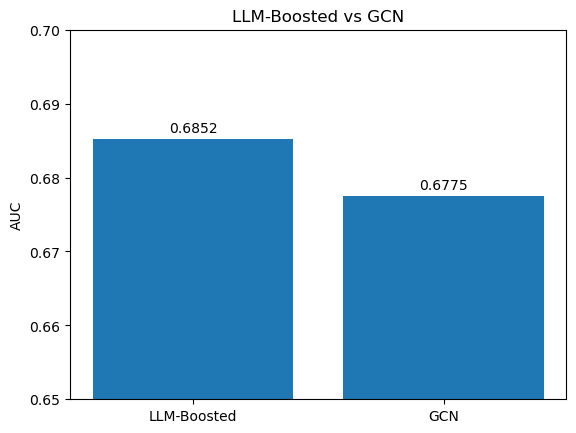

In [6]:
results = {'LLM-Boosted':0.6852, 'GCN':0.6775}
plt.bar(results.keys(), results.values())
plt.title('LLM-Boosted vs GCN')
plt.ylabel('AUC')

# Adjust y-axis limits to make the difference visually more pronounced
plt.ylim(0.65, 0.7) # Zoom in on the relevant range of AUC scores

# Add value labels on top of the bars for clarity
for i, (name, value) in enumerate(results.items()):
    plt.text(i, value + 0.0005, f"{value:.4f}", ha='center', va='bottom')

plt.show()

In [11]:
results = pd.read_csv("llm_gnn_results.csv")
LLM_pred = results['LLM_Prediction']>0.5
GCN_pred = results['GNN_Initial']>0.5
true_label = results['Actual_Label']

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

LLM_precision = precision_score(true_label, LLM_pred)
LLM_recall = recall_score(true_label, LLM_pred)
LLM_f1 = f1_score(true_label, LLM_pred)
LLM_accuracy = accuracy_score(true_label, LLM_pred)

GCN_precision = precision_score(true_label, GCN_pred)
GCN_recall = recall_score(true_label, GCN_pred)
GCN_f1 = f1_score(true_label, GCN_pred)
GCN_accuracy = accuracy_score(true_label, GCN_pred)

# Create a dictionary to hold the metrics
metrics_data = {
    'Precision': [LLM_precision, GCN_precision],
    'Recall': [LLM_recall, GCN_recall],
    'F1-Score': [LLM_f1, GCN_f1],
    'Accuracy': [LLM_accuracy, GCN_accuracy]
}

# Create a DataFrame
metrics_df = pd.DataFrame(metrics_data, index=['LLM', 'GCN'])

# Display the table
print("Performance Metrics:")
print(tabulate(metrics_df, headers='keys', tablefmt='grid'))




Performance Metrics:
+-----+-------------+----------+------------+------------+
|     |   Precision |   Recall |   F1-Score |   Accuracy |
+=====+=============+==========+============+============+
| LLM |    0.553571 | 0.869159 |   0.676364 |   0.563725 |
+-----+-------------+----------+------------+------------+
| GCN |    0.553459 | 0.82243  |   0.661654 |   0.558824 |
+-----+-------------+----------+------------+------------+
